# Run Direct in WSL

## Check Dir

In [1]:
import os
os.makedirs(os.path.expanduser('~/DPCC'), exist_ok=True)
print("✓ Working directory ready")

✓ Working directory ready


# Register the Kernel - Change the ipynb Kernel into dpcc

In [ ]:
# 1. Install the bridge into the dpcc environment
~/miniconda3/envs/dpcc/bin/pip install ipykernel -q

# 2. Now register the kernel
~/miniconda3/envs/dpcc/bin/python -m ipykernel install --user --name dpcc --display-name "Python 3.10 (dpcc)"

## Install Miniconda into Colab (to get Python 3.10)

In [ ]:
%%bash
if [ ! -f "$HOME/miniconda.sh" ]; then
    wget -q https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh \
        -O ~/miniconda.sh
fi
bash ~/miniconda.sh -b -p ~/miniconda3 -u
echo "✓ Miniconda installed"
~/miniconda3/bin/conda --version

PREFIX=/home/liu/miniconda3
Unpacking bootstrapper...
Unpacking payload...


## Clone the DPCC Repo

In [2]:
%%bash
cd ~/DPCC

if [ ! -d "dpcc" ]; then
    git clone --recurse-submodules "https://github.com/ghubliming/dpcc.git"
    echo "Cloned successfully."
else
    echo "Repo already exists, pulling latest..."
    cd dpcc && git pull
fi

Repo already exists, pulling latest...
Already up to date.


## Clone the D3IL

In [3]:
# ── Check if d3il exists and is populated, clone if not ──────
D3IL="$HOME/DPCC/dpcc/d3il"
PIP="$HOME/miniconda3/envs/dpcc/bin/pip"

echo "=== Checking d3il ==="
if [ ! -f "$D3IL/environments/d3il/setup.py" ]; then
    echo "d3il missing or empty — cloning from ALRhub..."
    rm -rf "$D3IL"
    git clone https://github.com/ALRhub/d3il.git "$D3IL"
    echo "✓ d3il cloned"
else
    echo "✓ d3il already exists, skipping clone"
fi

echo ""
echo "=== Verifying ==="
ls "$D3IL/environments/d3il/setup.py" \
    && echo "✓ d3il core setup.py found" \
    || { echo "✗ setup.py MISSING — clone may have failed"; exit 1; }

ls "$D3IL/environments/d3il/envs/gym_avoiding_env/setup.py" \
    && echo "✓ gym_avoiding_env setup.py found" \
    || { echo "✗ gym_avoiding_env setup.py MISSING"; exit 1; }

echo ""
echo "=== Installing D3IL ==="
$PIP install -e "$D3IL/environments/d3il" -q \
    && echo "✓ d3il core installed" \
    || { echo "✗ d3il core FAILED"; exit 1; }

$PIP install -e "$D3IL/environments/d3il/envs/gym_avoiding_env" -q \
    && echo "✓ gym_avoiding_env installed" \
    || { echo "✗ gym_avoiding_env FAILED"; exit 1; }

echo ""
echo "=== Done — D3IL ready ==="

SyntaxError: invalid syntax (2246324371.py, line 5)

## Create conda env with Python 3.10

In [ ]:
%%bash
~/miniconda3/bin/conda tos accept --override-channels \
    --channel https://repo.anaconda.com/pkgs/main
~/miniconda3/bin/conda tos accept --override-channels \
    --channel https://repo.anaconda.com/pkgs/r

~/miniconda3/bin/conda create -n dpcc python=3.10 -y -q
echo "✓ conda env 'dpcc' created with Python 3.10"
~/miniconda3/envs/dpcc/bin/python --version

accepted Terms of Service for https://repo.anaconda.com/pkgs/main
accepted Terms of Service for https://repo.anaconda.com/pkgs/r
Jupyter detected...
2 channel Terms of Service accepted
Retrieving notices: ...working... done
Channels:
 - defaults
Platform: linux-64
Solving environment: ...working... done

## Package Plan ##

  environment location: /content/miniconda3/envs/dpcc

  added / updated specs:
    - python=3.10


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ld_impl_linux-64-2.44      |       h9e0c5a2_3         725 KB
    libnsl-2.0.0               |       h5eee18b_0          31 KB
    packaging-25.0             |  py310h06a4308_1         164 KB
    python-3.10.20             |       h741d88c_0        24.1 MB
    setuptools-80.10.2         |  py310h06a4308_0         1.3 MB
    sqlite-3.51.1              |       h3e8d24a_1         1.2 MB
    tzdata-2026a               |       h

## Install PyTorch (CUDA124)

In [ ]:
%%bash
~/miniconda3/envs/dpcc/bin/pip install \
    torch torchvision \
    --index-url https://download.pytorch.org/whl/cpu -q
echo "✓ PyTorch (CPU) installed"
~/miniconda3/envs/dpcc/bin/python -c \
    "import torch; print('PyTorch:', torch.__version__); print('CUDA:', torch.cuda.is_available())"

✓ PyTorch installed
PyTorch: 2.6.0+cu124
CUDA: True


## Install All Requirements

In [4]:
%%bash
PIP="$HOME/miniconda3/envs/dpcc/bin/pip"
cd ~/DPCC/dpcc

echo "========================================="
echo " INSTALLING FROM requirements.txt"
echo "========================================="
echo "Using pip: $($PIP --version)"
echo ""

if [ ! -f requirements.txt ]; then
  echo "ERROR: requirements.txt not found in $(pwd)"
  exit 1
fi

echo "Found requirements.txt -- $(wc -l < requirements.txt) packages listed"
echo ""

PASS=0
FAIL=0
SKIP=0
FAILED_PKGS=()

while IFS= read -r line || [ -n "$line" ]; do
  [[ -z "$line" || "$line" == \#* ]] && continue

  PKG="$line"
  printf "  %-40s" "$PKG"

  RESULT=$($PIP install "$PKG" -q 2>&1)
  STATUS=$?

  if [ $STATUS -eq 0 ]; then
    if echo "$RESULT" | grep -q "already satisfied"; then
      echo "[ already installed ]"
      ((SKIP++))
    else
      echo "[ installed ]"
      ((PASS++))
    fi
  else
    echo "[ FAILED ]"
    echo "    └─ $(echo "$RESULT" | tail -3)"
    FAILED_PKGS+=("$PKG")
    ((FAIL++))
  fi

done < requirements.txt

echo ""
echo "========================================="
echo " SUMMARY"
echo "========================================="
printf "  %-25s %d\n" "Newly installed:"  "$PASS"
printf "  %-25s %d\n" "Already installed:" "$SKIP"
printf "  %-25s %d\n" "Failed:"           "$FAIL"

if [ ${#FAILED_PKGS[@]} -gt 0 ]; then
  echo ""
  echo "  Failed packages:"
  for pkg in "${FAILED_PKGS[@]}"; do
    echo "    - $pkg"
  done
  echo ""
  echo "Setup incomplete. Resolve the above before proceeding."
  exit 1
else
  echo ""
  echo "All packages installed successfully."
fi

 INSTALLING FROM requirements.txt
Using pip: pip 26.0.1 from /home/liu/miniconda3/envs/dpcc/lib/python3.10/site-packages/pip (python 3.10)

Found requirements.txt -- 144 packages listed

  absl-py==2.1.0                          [ installed ]
  accelerate==0.31.0                      [ installed ]
  cachetools==5.3.3                       [ installed ]
  casadi==3.6.5                           [ installed ]
  certifi==2024.6.2                       [ installed ]
  charset-normalizer==3.3.2               [ installed ]
  chex==0.1.86                            [ installed ]
  clarabel==0.9.0                         [ installed ]
  click==8.1.7                            [ installed ]
  cloudpickle==3.0.0                      [ installed ]
  cmeel==0.53.3                           [ installed ]
  cmeel-assimp==5.3.1                     [ installed ]
  cmeel-boost==1.83.0                     [ installed ]
  cmeel-console-bridge==1.0.2.2           [ installed ]
  cmeel-octomap==1.9.8.2     

## Install D3IL

In [ ]:
%%bash
D3IL_ROOT="$HOME/DPCC/dpcc/d3il"
PIP="$HOME/miniconda3/envs/dpcc/bin/pip"

$PIP install -e "$D3IL_ROOT/environments/d3il" -q
$PIP install -e "$D3IL_ROOT/environments/d3il/envs/gym_avoiding_env" -q
echo "✓ D3IL installed"

✓ D3IL installed


## Set PYTHONPATH and MuJoCo renderer

In [5]:
import sys, os

HOME = os.path.expanduser("~")
D3IL_ROOT   = f"{HOME}/DPCC/dpcc/d3il"
GYM_AV_PATH = f"{D3IL_ROOT}/environments/d3il/envs/gym_avoiding_env"

sys.path.insert(0, D3IL_ROOT)
sys.path.insert(0, GYM_AV_PATH)

os.environ["MUJOCO_GL"]         = "osmesa"
os.environ["PYOPENGL_PLATFORM"] = "osmesa"
os.environ["PYTHONPATH"]        = f"{D3IL_ROOT}:{GYM_AV_PATH}:" + os.environ.get("PYTHONPATH", "")
print("✓ Paths and env vars set")

✓ Paths and env vars set


## WSL install OSMesa (If Need)

In [ ]:
# ── Step 1: Install OSMesa system library ────────────────────
sudo apt update
sudo apt install -y libosmesa6 libosmesa6-dev

# ── Step 2: Verify it's now found ────────────────────────────
echo "=== OSMesa after install ==="
ldconfig -p | grep -i osmesa

echo ""
echo "=== Python finds it now? ==="
~/miniconda3/envs/dpcc/bin/python -c "
import ctypes.util
print('OSMesa:', ctypes.util.find_library('OSMesa'))
"

# ── Step 3: Test mujoco imports cleanly ──────────────────────
echo ""
echo "=== MuJoCo test ==="
MUJOCO_GL=osmesa PYOPENGL_PLATFORM=osmesa \
    ~/miniconda3/envs/dpcc/bin/python -c "
import mujoco
print('✓ mujoco', mujoco.__version__)
"

# Here Start in Jupyter Notebook

## Full verification

In [2]:
%%bash
PYTHON="$HOME/miniconda3/envs/dpcc/bin/python"
D3IL_ROOT="$HOME/DPCC/dpcc/d3il"
GYM_AV="$D3IL_ROOT/environments/d3il/envs/gym_avoiding_env"

export PYTHONPATH="$D3IL_ROOT:$GYM_AV"
export MUJOCO_GL="osmesa"
export PYOPENGL_PLATFORM="osmesa"
export LD_PRELOAD="/usr/lib/x86_64-linux-gnu/libstdc++.so.6"
export LD_LIBRARY_PATH="/usr/lib/x86_64-linux-gnu:$LD_LIBRARY_PATH"

$PYTHON - << 'EOF'
import warnings
warnings.filterwarnings("ignore")
import sys

print(f"Python:  {sys.version}")

import torch
print(f"✓ PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}")

import mujoco
print(f"✓ mujoco {mujoco.__version__}")

from environments.d3il import d3il_sim
print("✓ environments.d3il.d3il_sim")

from environments.d3il.envs.gym_avoiding_env.gym_avoiding.envs.avoiding import ObstacleAvoidanceEnv
env = ObstacleAvoidanceEnv(render=False)
env.start()
obs = env.reset()
print(f"✓ ObstacleAvoidanceEnv OK | obs shape: {obs.shape}")

print("")
print("========================================")
print(" ALL CHECKS PASSED — ready to train!")
print("========================================")
EOF

pybullet build time: Nov 28 2023 23:45:17


Python:  3.10.20 (main, Mar 11 2026, 17:46:40) [GCC 14.3.0]
✓ PyTorch 2.10.0+cpu | CUDA: False
✓ mujoco 2.3.7
✓ environments.d3il.d3il_sim
Final IK error (78 iterations):  7.285862274065073e-06
Final IK error (0 iterations):  7.285862274065073e-06
✓ ObstacleAvoidanceEnv OK | obs shape: (2,)

 ALL CHECKS PASSED — ready to train!



# Handle Gurobi

In [7]:
import os
os.environ['GRB_LICENSE_FILE'] = os.path.expanduser('~/DPCC/gurobi.lic')

# Set Up wandb

In [3]:
!echo $WANDB_MODE

# the WANDB MUST upgrade, other wont work

In [ ]:
~/miniconda3/envs/dpcc/bin/pip install --upgrade wandb

In [3]:
import wandb
import os

# 1. Ensure any previous run in this process is closed safely
if wandb.run is not None:
    wandb.finish()

# 2. Clean initialization
# Using a 'with' block is often safer as it handles the finish() automatically
run = wandb.init(
    project="DPCC-CPU",
    mode="online",  # Fixed the syntax error here
    reinit=True     # Allows multiple wandb.init() calls in the same notebook/script
)

# 3. Verification
print(f"Current Mode: {wandb.run.settings.mode}")
print(f"Run URL: {run.url}")

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Current Mode: online
Run URL: https://wandb.ai/llmmail2021-technical-university-of-munich/DPCC-CPU/runs/q2uc84lv


# Dataset download

%%bash
ZIP="/content/drive/MyDrive/DPCC/dpcc/d3il/environments/dataset/data/dataset.zip"

echo "=== Top-level folders in zip ==="
unzip -l "$ZIP" | awk '{print $4}' | cut -d'/' -f1 | sort -u

echo ""
echo "=== File count per folder ==="
unzip -l "$ZIP" | awk '{print $4}' | cut -d'/' -f1 | sort | uniq -c | sort -rn

echo ""
echo "=== Total uncompressed size ==="
unzip -l "$ZIP" | tail -1

```
=== Top-level folders in zip ===

----
aligning
avoiding
inserting
Name
pushing
sorting
stacking

=== File count per folder ===
2638779 sorting
1377112 stacking
 392768 aligning
   2002 pushing
    802 inserting
     99 avoiding
      3
      1 Name
      1 ----

=== Total uncompressed size ===
17689115292                     4411562 files

Only Extract the avoiding

In [4]:
%%bash
DATASET_DIR="$HOME/DPCC/dpcc/d3il/environments/dataset/data"
AVOIDING_DATA="$DATASET_DIR/avoiding/data"
ZIP_FILE="$DATASET_DIR/dataset.zip"

echo "========================================="
echo " D3IL DATASET SETUP"
echo " Source: ALRhub/d3il README.md"
echo " Link: https://drive.google.com/file/d/1SQhbhzV85zf_ltnQ8Cbge2lsSWInxVa8"
echo "========================================="
echo ""

# ── Step 1: Check if avoiding data already extracted ─────────────
if [ -d "$AVOIDING_DATA" ] && [ "$(ls -A $AVOIDING_DATA)" ]; then
    echo "✓ Dataset already extracted at: $AVOIDING_DATA"
    echo "  Files: $(ls $AVOIDING_DATA | wc -l) found"
    echo "  Skipping download and extraction."
    exit 0
fi

# ── Step 2: Check if zip already downloaded ───────────────────────
if [ -f "$ZIP_FILE" ]; then
    echo "✓ Zip already exists: $(du -sh $ZIP_FILE | cut -f1)"
    echo "  Skipping download."
else
    echo "Zip not found. Downloading..."
    mkdir -p "$DATASET_DIR"

    $HOME/miniconda3/envs/dpcc/bin/pip install gdown -q
    echo "✓ gdown ready"

    $HOME/miniconda3/envs/dpcc/bin/python -m gdown \
        "https://drive.google.com/uc?id=1SQhbhzV85zf_ltnQ8Cbge2lsSWInxVa8" \
        -O "$ZIP_FILE"

    if [ ! -f "$ZIP_FILE" ]; then
        echo "✗ Download failed — zip file not found"
        exit 1
    fi
    echo "✓ Downloaded: $(du -sh $ZIP_FILE | cut -f1)"
fi
echo ""

# ── Step 3: Extract ONLY avoiding/ to local disk (fast) ────
echo "Extracting only avoiding/ to local disk first..."
LOCAL="/tmp/avoiding_tmp"
mkdir -p "$LOCAL"
unzip -q "$ZIP_FILE" "avoiding/*" -d "$LOCAL"

if [ $? -ne 0 ]; then
    echo "✗ Extraction failed"
    rm -rf "$LOCAL"
    exit 1
fi
echo "✓ Extracted locally: $(find $LOCAL -type f | wc -l) files | $(du -sh $LOCAL | cut -f1)"
echo ""

# ── Step 4: Copy only avoiding/ to dataset path ───────────────────
echo "Copying avoiding/ to dataset path..."
mkdir -p "$DATASET_DIR/avoiding"
cp -r "$LOCAL/avoiding/." "$DATASET_DIR/avoiding/"
echo "✓ Copied"

# ── Step 5: Cleanup local temp ────────────────────────────────────
rm -rf "$LOCAL"
echo "✓ Local temp cleaned up"
echo ""

# ── Step 6: Final verification ────────────────────────────────────
echo "========================================="
echo " VERIFICATION"
echo "========================================="
if [ -d "$AVOIDING_DATA" ] && [ "$(ls -A $AVOIDING_DATA)" ]; then
    echo "✓ avoiding/data found"
    echo "  Files: $(ls $AVOIDING_DATA | wc -l)"
    echo "  Sample: $(ls $AVOIDING_DATA | head -3)"
    echo ""
    echo "✓ Dataset ready — you can now run the smoke test."
else
    echo "✗ avoiding/data still not found."
    echo "  Actual structure:"
    find "$DATASET_DIR" -maxdepth 3 | sort | head -20
    exit 1
fi

 D3IL DATASET SETUP
 Source: ALRhub/d3il README.md
 Link: https://drive.google.com/file/d/1SQhbhzV85zf_ltnQ8Cbge2lsSWInxVa8

✓ Dataset already extracted at: /home/liu/DPCC/dpcc/d3il/environments/dataset/data/avoiding/data
  Files: 96 found
  Skipping download and extraction.


## Minors before running in WSL CPU 

Uninstall triton completely — not needed for CPU

In [ ]:
# Uninstall triton completely — not needed for CPU
~/miniconda3/envs/dpcc/bin/pip uninstall triton -y

echo "✓ triton removed"

# Verify it's gone
~/miniconda3/envs/dpcc/bin/python -c "import triton" 2>&1 \
    && echo "still installed" \
    || echo "✓ triton gone"

Remove Hard Coded GPU CUDA

In [ ]:
# ── Fix 1: arrays.py — change default DEVICE to cpu ─────────
sed -i "s/DEVICE = 'cuda:0'/DEVICE = 'cpu'/" \
    ~/DPCC/dpcc/diffuser/utils/arrays.py

sed -i "s/def batch_to_device(batch, device='cuda:0'):/def batch_to_device(batch, device='cpu'):/" \
    ~/DPCC/dpcc/diffuser/utils/arrays.py

sed -i "s/def to_device(x, device=DEVICE):/def to_device(x, device='cpu'):/" \
    ~/DPCC/dpcc/diffuser/utils/arrays.py

# ── Fix 2: training.py — change default train_device to cpu ──
sed -i "s/train_device='cuda'/train_device='cpu'/" \
    ~/DPCC/dpcc/diffuser/utils/training.py

sed -i "s/pin_memory=True/pin_memory=False/g" \
    ~/DPCC/dpcc/diffuser/utils/training.py

# ── Verify changes ────────────────────────────────────────────
echo "=== arrays.py ==="
grep -n "DEVICE\|batch_to_device\|to_device" \
    ~/DPCC/dpcc/diffuser/utils/arrays.py | head -10

echo ""
echo "=== training.py ==="
grep -n "train_device\|pin_memory" \
    ~/DPCC/dpcc/diffuser/utils/training.py

# Smoke Test Training Cell

%%bash
PYTHON="$HOME/miniconda3/envs/dpcc/bin/python"
PIP="$HOME/miniconda3/envs/dpcc/bin/pip"
DPCC="$HOME/DPCC/dpcc"
D3IL_ROOT="$DPCC/d3il"
GYM_AV="$D3IL_ROOT/environments/d3il/envs/gym_avoiding_env"

export PYTHONPATH="$DPCC:$D3IL_ROOT:$GYM_AV"
export MUJOCO_GL="osmesa"
export WANDB_MODE="offline"
export MPLBACKEND="agg"

cd $DPCC

# Force reinstall gymnasium and minari to resolve potential import issues
$PIP install --force-reinstall gymnasium minari -q

$PYTHON - << 'EOF'
import matplotlib
matplotlib.use('agg')   # force non-interactive backend before any other import

import torch
import diffuser.utils as utils

exp = 'avoiding-d3il'
seeds = [5]

class Parser(utils.Parser):
    dataset: str = exp
    config: str = 'config.' + exp

for seed in seeds:
    args = Parser().parse_args(experiment='diffusion', seed=seed)
    torch.manual_seed(args.seed)

    # Smoke test overrides
    args.n_train_steps     = 10
    args.n_steps_per_epoch = 10
    args.batch_size        = 2
    args.device            = 'cpu'

    print(f"Smoke test: seed={seed} | steps={args.n_train_steps} | batch={args.batch_size}")

    dataset_config = utils.Config(
        args.loader,
        savepath=(args.savepath, 'dataset_config.pkl'),
        env=args.dataset,
        horizon=args.horizon,
        normalizer=args.normalizer,
        preprocess_fns=args.preprocess_fns,
        use_padding=args.use_padding,
        max_path_length=args.max_path_length,
        include_returns=args.include_returns,
        returns_scale=args.max_path_length,
        discount=args.discount,
    )
    dataset = dataset_config()
    observation_dim = dataset.observation_dim
    action_dim      = dataset.action_dim
    goal_dim        = dataset.goal_dim

    model_config = utils.Config(
        args.model,
        savepath=(args.savepath, 'model_config.pkl'),
        horizon=args.horizon,
        transition_dim=observation_dim + action_dim,
        cond_dim=observation_dim,
        dim_mults=args.dim_mults,
        returns_condition=args.returns_condition,
        dim=args.dim,
        condition_dropout=args.condition_dropout,
        device=args.device,
    )

    diffusion_config = utils.Config(
        args.diffusion,
        savepath=(args.savepath, 'diffusion_config.pkl'),
        horizon=args.horizon,
        observation_dim=observation_dim,
        action_dim=action_dim,
        goal_dim=goal_dim,
        n_timesteps=args.n_diffusion_steps,
        loss_type=args.loss_type,
        clip_denoised=args.clip_denoised,
        predict_epsilon=args.predict_epsilon,
        action_weight=args.action_weight,
        loss_discount=args.loss_discount,
        returns_condition=args.returns_condition,
        condition_guidance_w=args.condition_guidance_w,
        device=args.device,
    )

    trainer_config = utils.Config(
        utils.Trainer,
        savepath=(args.savepath, 'trainer_config.pkl'),
        train_test_split=args.train_test_split,
        ema_decay=args.ema_decay,
        n_train_steps=args.n_train_steps,
        n_steps_per_epoch=args.n_steps_per_epoch,
        train_batch_size=args.batch_size,
        train_lr=args.learning_rate,
        gradient_accumulate_every=args.gradient_accumulate_every,
        results_folder=args.savepath,
    )

    model     = model_config()
    diffusion = diffusion_config(model)
    trainer   = trainer_config(diffusion, dataset)

    trainer.train()
    print(f"\n✓ Smoke test PASSED — seed {seed} completed {args.n_train_steps} steps")

print("\n========================================")
print(" SMOKE TEST COMPLETE — DPCC code works!")
print("========================================")
EOF

Before Real Training - change device cuda → cpu

In [ ]:
# ── Fix config file: change device cuda → cpu ────────────────
sed -i "s/'device': 'cuda'/'device': 'cpu'/" \
    ~/DPCC/dpcc/config/avoiding-d3il.py

# Also fix any 'cuda:0' variant
sed -i "s/'device': 'cuda:0'/'device': 'cpu'/" \
    ~/DPCC/dpcc/config/avoiding-d3il.py

# ── Verify ───────────────────────────────────────────────────
echo "=== config/avoiding-d3il.py device line ==="
grep -n "device" ~/DPCC/dpcc/config/avoiding-d3il.py

 # Train (using the conda env Python)

In [6]:
%%bash
DPCC="$HOME/DPCC/dpcc"
D3IL_ROOT="$DPCC/d3il"
GYM_AV="$D3IL_ROOT/environments/d3il/envs/gym_avoiding_env"

cd $DPCC

export MUJOCO_GL=osmesa
export PYOPENGL_PLATFORM=osmesa
export WANDB_MODE=offline
export MPLBACKEND=agg
export PYTHONPATH="$DPCC:$D3IL_ROOT:$GYM_AV"
#                   ↑ this was missing — diffuser/ is inside here

~/miniconda3/envs/dpcc/bin/python scripts/train.py


[utils/config ] Config: <class 'diffuser.datasets.sequence.SequenceDataset'>
    discount: 0.99
    env: avoiding-d3il
    horizon: 8
    include_returns: True
    max_path_length: 150
    normalizer: LimitsNormalizer
    preprocess_fns: []
    returns_scale: 150
    use_padding: True

[ utils/config ] Saved config to: logs/avoiding-d3il/diffusion/H8_K20_Dmodels.GaussianDiffusion/5/dataset_config.pkl

[ datasets/buffer ] Fields:
    observations: (96, 150, 4)
    actions: (96, 150, 2)
    rewards: (96, 150, 1)
    terminals: (96, 150, 1)
    normed_observations: (96, 150, 4)
    normed_actions: (96, 150, 2)

[utils/config ] Config: <class 'diffuser.models.unet1d_temporal_cond.UNet1DTemporalCondModel'>
    cond_dim: 4
    condition_dropout: 0.25
    dim: 32
    dim_mults: (1, 2, 4, 8)
    horizon: 8
    returns_condition: False
    transition_dim: 6

[ utils/config ] Saved config to: logs/avoiding-d3il/diffusion/H8_K20_Dmodels.GaussianDiffusion/5/model_config.pkl


[utils/config ] Conf

Epoch 0:  40%|████      | 405/1000 [00:39<00:54, 10.89it/s, a0_loss=0.0547, a0_loss_test=0.109, diffusion_loss=0.951, loss=0.475, loss_test=0.757, lr=4.05e-5, step=404] 

Initial test loss:   0.7571, a0 loss:   0.1095


Epoch 66:  42%|████▏     | 417/1000 [00:43<00:53, 11.00it/s, a0_loss=0.00775, a0_loss_test=0.00817, diffusion_loss=0.0609, loss=0.0304, loss_test=0.0325, lr=2.58e-5, step=66416]Traceback (most recent call last):
  File "/home/liu/DPCC/dpcc/scripts/train.py", line 131, in <module>
    trainer.train()
  File "/home/liu/DPCC/dpcc/diffuser/utils/training.py", line 188, in train
    self.train_epoch(self.n_steps_per_epoch, epoch)
  File "/home/liu/DPCC/dpcc/diffuser/utils/training.py", line 126, in train_epoch
    loss.backward()
  File "/home/liu/miniconda3/envs/dpcc/lib/python3.10/site-packages/torch/_tensor.py", line 630, in backward
    torch.autograd.backward(
  File "/home/liu/miniconda3/envs/dpcc/lib/python3.10/site-packages/torch/autograd/__init__.py", line 364, in backward
    _engine_run_backward(
  File "/home/liu/miniconda3/envs/dpcc/lib/python3.10/site-pack

Process was interrupted.


ages/torch/autograd/graph.py", line 865, in _engine_run_backward
    return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
KeyboardInterrupt


CalledProcessError: Command 'b'DPCC="$HOME/DPCC/dpcc"\nD3IL_ROOT="$DPCC/d3il"\nGYM_AV="$D3IL_ROOT/environments/d3il/envs/gym_avoiding_env"\n\ncd $DPCC\n\nexport MUJOCO_GL=osmesa\nexport PYOPENGL_PLATFORM=osmesa\nexport WANDB_MODE=offline\nexport MPLBACKEND=agg\nexport PYTHONPATH="$DPCC:$D3IL_ROOT:$GYM_AV"\n#                   \xe2\x86\x91 this was missing \xe2\x80\x94 diffuser/ is inside here\n\n~/miniconda3/envs/dpcc/bin/python scripts/train.py\n'' died with <Signals.SIGINT: 2>.

Epoch 66:  42%|████▏     | 417/1000 [00:44<01:02,  9.27it/s, a0_loss=0.00775, a0_loss_test=0.00817, diffusion_loss=0.0609, loss=0.0304, loss_test=0.0325, lr=2.58e-5, step=66416]


# Evaluate

## CPU Evaluation Updates (Code Changes Outside This Notebook)

The evaluation now runs on CPU because the following source code updates were made outside this notebook:

- `dpcc/projection_eval.py`
  - Added robust local path setup (`sys.path`) for D3IL/gym-avoiding imports.
  - Standardized runtime device handling to CPU via `CPU_DEVICE = 'cpu'`.
  - Kept CPU fallback when loading diffusion checkpoints.

- `dpcc/diffuser/utils/serialization.py`
  - Forced loaded config objects (`model_config`, `diffusion_config`) to honor the requested runtime device.
  - Set trainer runtime device from the same requested device.

- `dpcc/diffuser/utils/training.py`
  - Changed checkpoint loading to `torch.load(..., map_location=self.device)` so CUDA-trained checkpoints load on CPU-only Torch.

- `dpcc/diffuser/sampling/policies.py`
  - Removed hardcoded CUDA tensor placement in policy sampling.
  - Returns and condition tensors now use the model device (CPU-safe).

These changes are persistent in the Python source files, so the Evaluate cell can stay simple and just run `projection_eval.py` on CPU.

In [ ]:
for WSL need

In [ ]:
# ── Downgrade numpy to 1.x ───────────────────────────────────
~/miniconda3/envs/dpcc/bin/pip install "numpy<2" -q

# ── Verify ───────────────────────────────────────────────────
~/miniconda3/envs/dpcc/bin/python -c "import numpy; print('numpy', numpy.__version__)"
# Should show: numpy 1.26.x

# ── Quick test pinocchio loads ────────────────────────────────
~/miniconda3/envs/dpcc/bin/python -c "import pinocchio; print('✓ pinocchio OK')"

then Run

Notice here we use a modified temp version  projection_eval.py under root path! 
only Temp solution. Cuda-cpu issue.

In [35]:
%%bash
DPCC="$HOME/DPCC/dpcc"
D3IL_ROOT="$DPCC/d3il"
GYM_AV="$D3IL_ROOT/environments/d3il/envs/gym_avoiding_env"

cd $DPCC

export CUDA_VISIBLE_DEVICES=""
export MUJOCO_GL=osmesa
export PYOPENGL_PLATFORM=osmesa
export WANDB_MODE=offline
export MPLBACKEND=agg
export PYTHONPATH="$DPCC:$D3IL_ROOT:$GYM_AV"

$HOME/miniconda3/envs/dpcc/bin/python projection_eval.py

echo "Done!"

pybullet build time: Nov 28 2023 23:45:17
/home/liu/DPCC/dpcc/projection_eval.py:365: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/home/liu/DPCC/dpcc/projection_eval.py:66: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  figs_all_seeds, axes_all_seeds = zip(*[plt.subplots(1, 1, figsize=(9, 10)) for _ in range(len(projection_variants))])
/home/liu/miniconda3/envs/dpcc/lib/python3.10/site-packages/scipy/optimize/_slsqp_py.py:437: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)



Loading model for seed 5...

[ utils/serialization ] Loading model from logs/avoiding-d3il/diffusion/H8_K20_Dmodels.GaussianDiffusion/5

[ datasets/buffer ] Fields:
    observations: (96, 150, 4)
    actions: (96, 150, 2)
    rewards: (96, 150, 1)
    terminals: (96, 150, 1)
    normed_observations: (96, 150, 4)
    normed_actions: (96, 150, 2)
Final IK error (78 iterations):  7.285862274065073e-06
Final IK error (0 iterations):  7.285862274065073e-06

--- Running avoiding-d3il - top-right-hard - dpcc-r (seed 5) ---
Success rate: 1.00
Constraints satisfied: 0.50
Success rate (goal and constraints): 0.50
Avg number of steps: 64.50 +- 5.50
Avg number of constraint violations: 1.50 +- 1.50
Avg total violation: 0.007 +- 0.007
Average computation time per step: 0.574

--- Running avoiding-d3il - top-right-hard - dpcc-r-tightened (seed 5) ---
Success rate: 1.00
Constraints satisfied: 1.00
Success rate (goal and constraints): 1.00
Avg number of steps: 68.50 +- 6.50
Avg number of constraint v

#  Visualize

In [24]:
%%bash
DPCC="$HOME/DPCC/dpcc"
D3IL_ROOT="$DPCC/d3il"
GYM_AV="$D3IL_ROOT/environments/d3il/envs/gym_avoiding_env"

cd $DPCC

unset MPLBACKEND
export MPLBACKEND=agg
export MUJOCO_GL=osmesa
export PYOPENGL_PLATFORM=osmesa
export PYTHONPATH="$DPCC:$D3IL_ROOT:$GYM_AV"

$HOME/miniconda3/envs/dpcc/bin/python scripts/visualize_data_constraints.py

/home/liu/DPCC/dpcc/scripts/visualize_data_constraints.py:165: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Halfspace variant: top-right-hard
Number of feasible trajectories: 1/96, 1.04%
Halfspace variant: top-left-hard
Number of feasible trajectories: 0/96, 0.00%
Halfspace variant: both-hard
Number of feasible trajectories: 2/96, 2.08%


get the png

In [ ]:
find ~/DPCC/dpcc -name "*.png" -newer ~/DPCC/dpcc/scripts/visualize_data_constraints.py \
    | sort | head -20

In [ ]:
# Load Resut

In [36]:
%%bash
DPCC="$HOME/DPCC/dpcc"
D3IL_ROOT="$DPCC/d3il"
GYM_AV="$D3IL_ROOT/environments/d3il/envs/gym_avoiding_env"

cd $DPCC

unset MPLBACKEND
export MPLBACKEND=agg
export MUJOCO_GL=osmesa
export PYOPENGL_PLATFORM=osmesa
export PYTHONPATH="$DPCC:$D3IL_ROOT:$GYM_AV"

$HOME/miniconda3/envs/dpcc/bin/python scripts/load_results.py

/home/liu/DPCC/dpcc/scripts/load_results.py:123: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/home/liu/DPCC/dpcc/scripts/load_results.py:141: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/home/liu/DPCC/dpcc/scripts/load_results.py:123: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/home/liu/DPCC/dpcc/scripts/load_results.py:141: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


------------------ Variant: dpcc-r ------------------
Success rate (goal): 1.00
Success rate (goal + constraints): 0.33
Success rate (constraints): 0.33
Average steps: 62.83 +- 4.22
Average violations: 2.50 +- 2.14
Average total violations: 0.013 +- 0.015
Average time: 0.52 +- 0.01
$62.8 \pm 4.2$ & $1.00$ & $0.33$ & $2.5 \pm 2.1$ \\
------------------ Variant: dpcc-r-tightened ------------------
Success rate (goal): 1.00
Success rate (goal + constraints): 1.00
Success rate (constraints): 1.00
Average steps: 64.50 +- 6.34
Average violations: 0.00 +- 0.00
Average total violations: 0.000 +- 0.000
Average time: 0.52 +- 0.01
$64.5 \pm 6.3$ & $1.00$ & $1.00$ & $0.0 \pm 0.0$ \\
------------------ Variant: dpcc-c ------------------
Success rate (goal): 0.83
Success rate (goal + constraints): 0.17
Success rate (constraints): 0.17
Average steps: 87.40 +- 14.44
Average violations: 17.33 +- 17.90
Average total violations: 0.366 +- 0.420
Average time: 0.39 +- 0.01
$87.4 \pm 14.4$ & $0.83$ & $0.17$ 

# FM Test

chang the dpcc/flow_matcher/utils/training.py cuda -> CPU

avoiding-d3il changed into 
        # training
        #'n_steps_per_epoch': 1000,
        #'n_steps_per_epoch': 10,
        'n_steps_per_epoch': 5,
        #'n_train_steps': 1e5,
        'n_train_steps': 10,
        #'batch_size': 8,
        'batch_size': 2,
        'learning_rate': 1e-4,
        #'gradient_accumulate_every': 2,
        'gradient_accumulate_every': 1,
        'ema_decay': 0.995,
        #'train_test_split': 0.9,
        'train_test_split': 1,
        'device': 'cpu',
        'seed': 0,
    },

in ~lin60 utils/training.py
Prevent too small training steps, /0 bug.
#self.save_freq = n_train_steps // 5
self.save_freq = max(1, n_train_steps // 5)

In [3]:
%%bash
DPCC="$HOME/DPCC/dpcc"
D3IL_ROOT="$DPCC/d3il"
GYM_AV="$D3IL_ROOT/environments/d3il/envs/gym_avoiding_env"

cd $DPCC

export MUJOCO_GL=osmesa
export PYOPENGL_PLATFORM=osmesa
export WANDB_MODE=offline
export MPLBACKEND=agg
export PYTHONPATH="$DPCC:$D3IL_ROOT:$GYM_AV"

 ~/miniconda3/envs/dpcc/bin/python FM_test/train_FM.py

[ train ] Seed source: default
[ train ] Training seeds: [5]
[ train ] Saved seed manifest to: logs/avoiding-d3il/flow_matching/H4_K2_Dmodels.diffusion.GaussianDiffusion/seeds_config.json

[utils/config ] Config: <class 'flow_matcher.datasets.sequence.SequenceDataset'>
    discount: 0.99
    env: avoiding-d3il
    horizon: 4
    include_returns: True
    max_path_length: 150
    normalizer: LimitsNormalizer
    preprocess_fns: []
    returns_scale: 150
    use_padding: True

[ utils/config ] Saved config to: logs/avoiding-d3il/flow_matching/H4_K2_Dmodels.diffusion.GaussianDiffusion/5/dataset_config.pkl

[ datasets/buffer ] Fields:
    observations: (96, 150, 4)
    actions: (96, 150, 2)
    rewards: (96, 150, 1)
    terminals: (96, 150, 1)
    normed_observations: (96, 150, 4)
    normed_actions: (96, 150, 2)

[utils/config ] Config: <class 'flow_matcher.models.unet1d_temporal_cond.UNet1DTemporalCondModel'>
    cond_dim: 4
    condition_dropout: 0.25
    dim: 16
    dim_mults: (1, 2)
 

Epoch 0:   0%|          | 0/1 [00:00<?, ?it/s]/home/liu/miniconda3/envs/dpcc/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch 1: 100%|██████████| 1/1 [00:00<00:00, 20.78it/s, a0_loss=0.0956, diffusion_loss=2.42, loss=2.42, lr=2e-7, step=1]


FM training completed.


Use the version of /eval_FM_CPU.py!

In [5]:
%%bash
DPCC="$HOME/DPCC/dpcc"
D3IL_ROOT="$DPCC/d3il"
GYM_AV="$D3IL_ROOT/environments/d3il/envs/gym_avoiding_env"

cd $DPCC

unset MPLBACKEND
export MPLBACKEND=agg
export MUJOCO_GL=osmesa
export PYOPENGL_PLATFORM=osmesa
export PYTHONPATH="$DPCC:$D3IL_ROOT:$GYM_AV"

$HOME/miniconda3/envs/dpcc/bin/python FM_test/eval_FM_CPU.py

pybullet build time: Nov 28 2023 23:45:17
/home/liu/DPCC/dpcc/FM_test/eval_FM_CPU.py:288: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


[ utils/setup ] Made savepath: logs/avoiding-d3il/plans/H8_K20_Dmodels.diffusion.GaussianDiffusion/6

Loading model for seed 6...

[ utils/serialization ] Loading model from logs/avoiding-d3il/flow_matching/H8_K20_Dmodels.diffusion.GaussianDiffusion/6

[ datasets/buffer ] Fields:
    observations: (96, 150, 4)
    actions: (96, 150, 2)
    rewards: (96, 150, 1)
    terminals: (96, 150, 1)
    normed_observations: (96, 150, 4)
    normed_actions: (96, 150, 2)
Final IK error (78 iterations):  7.285862274065073e-06
Final IK error (0 iterations):  7.285862274065073e-06
------------------------Running avoiding-d3il - top-right-hard - dpcc-r (6)----------------------------
Success rate: 0.0
Constraints satisfied: 0.0
Success rate (goal and constraints): 0.0
Avg number of steps: 0.00 +- 0.00
Avg number of constraint violations: 0.00 +- 0.00
Avg total violation: 0.000 +- 0.000
Average computation time per step: 0.101
------------------------Running avoiding-d3il - top-right-hard - dpcc-r-tight

load_result! Require the training seed finished

In [4]:
%%bash
DPCC="$HOME/DPCC/dpcc"
D3IL_ROOT="$DPCC/d3il"
GYM_AV="$D3IL_ROOT/environments/d3il/envs/gym_avoiding_env"

cd $DPCC

unset MPLBACKEND
export MPLBACKEND=agg
export MUJOCO_GL=osmesa
export PYOPENGL_PLATFORM=osmesa
export PYTHONPATH="$DPCC:$D3IL_ROOT:$GYM_AV"

$HOME/miniconda3/envs/dpcc/bin/python scripts/load_results.py

[ utils/setup ] Made savepath: logs/avoiding-d3il/plans/H8_K20_Dmodels.GaussianDiffusion/6


Traceback (most recent call last):
  File "/home/liu/DPCC/dpcc/scripts/load_results.py", line 37, in <module>
    data = np.load(f'{args.savepath}/results/halfspace_{halfspace_variant}/{variant}.npz', allow_pickle=True)
  File "/home/liu/miniconda3/envs/dpcc/lib/python3.10/site-packages/numpy/lib/npyio.py", line 427, in load
    fid = stack.enter_context(open(os_fspath(file), "rb"))
FileNotFoundError: [Errno 2] No such file or directory: 'logs/avoiding-d3il/plans/H8_K20_Dmodels.GaussianDiffusion/6/results/halfspace_top-right-hard/dpcc-r.npz'


CalledProcessError: Command 'b'DPCC="$HOME/DPCC/dpcc"\nD3IL_ROOT="$DPCC/d3il"\nGYM_AV="$D3IL_ROOT/environments/d3il/envs/gym_avoiding_env"\n\ncd $DPCC\n\nunset MPLBACKEND\nexport MPLBACKEND=agg\nexport MUJOCO_GL=osmesa\nexport PYOPENGL_PLATFORM=osmesa\nexport PYTHONPATH="$DPCC:$D3IL_ROOT:$GYM_AV"\n\n$HOME/miniconda3/envs/dpcc/bin/python scripts/load_results.py\n'' returned non-zero exit status 1.

# Load the Plan Npz Logs

In [6]:
import numpy as np

# Path to your specific file
file_path = 'dpcc/logs/avoiding-d3il/plans/H8_K20_Dmodels.diffusion.GaussianDiffusion/6/results/halfspace_top-right-hard/dpcc-t.npz'

# allow_pickle=True is MANDATORY for 'object' dtypes in npz
# Using a context manager ('with') is safer for file I/O
with np.load(file_path, allow_pickle=True) as data:
    
    # Force NumPy to print the entire array instead of truncating with "..."
    np.set_printoptions(threshold=np.inf, precision=6, suppress=True)
    
    print(f"{'Key':<25} | {'Shape':<15} | {'Data Type':<10}")
    print("=" * 60)

    for key in data.files:
        array = data[key]
        
        # Header for each entry
        print(f"{key:<25} | {str(array.shape):<15} | {str(array.dtype):<10}")
        
        # Logic to handle potential object arrays or nested dicts
        if array.dtype == 'object':
            print("--- Object Content ---")
            print(array.tolist()) # Converting to list often reveals the internal structure
        else:
            print(array)
            
        print("-" * 60)

Key                       | Shape           | Data Type 
n_success                 | (2,)            | float64   
[0. 0.]
------------------------------------------------------------
n_success_and_constraints | (2,)            | float64   
[0. 0.]
------------------------------------------------------------
n_steps                   | (2,)            | float64   
[9. 9.]
------------------------------------------------------------
n_violations              | (2,)            | float64   
[0. 0.]
------------------------------------------------------------
total_violations          | (2,)            | float64   
[0. 0.]
------------------------------------------------------------
avg_time                  | (2,)            | float64   
[0.102452 0.095426]
------------------------------------------------------------
collision_free_completed  | (2,)            | float64   
[0. 0.]
------------------------------------------------------------
args                      | ()              | obj

# load the training logs

Run identifier: flow_matching__H8_K20_GaussianDiffusion__6

Found 12 files in: dpcc/logs/avoiding-d3il/flow_matching/H8_K20_Dmodels.diffusion.GaussianDiffusion/6

============================== FILE: model_config.pkl ==============================
  Type: Config
  _class: <class '__main__.UNet1DTemporalCondModel'>
  _device: cuda
  _dict: {'horizon': 8, 'transition_dim': 6, 'cond_dim': 4, 'dim_mults': (1, 2, 4, 8), 'returns_condition': False, 'dim': 32, 'condition_dropout': 0.25}
--------------------------------------------------------------------------------
============================== FILE: state_best.pt ==============================
Keys in Checkpoint: ['step', 'model', 'ema']
--------------------------------------------------------------------------------
============================== FILE: dataset_config.pkl ==============================
  Type: Config
  _class: <class '__main__.SequenceDataset'>
  _device: None
  _dict: {'env': 'avoiding-d3il', 'horizon': 8, 'normalizer': '

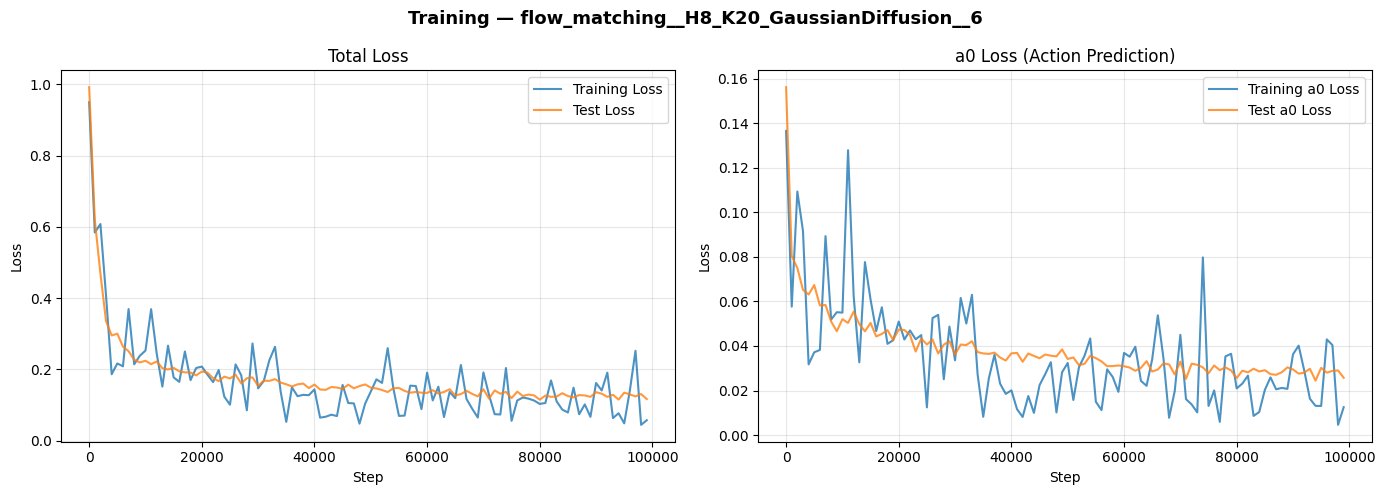


✅ Loss curves saved to dpcc/logs/avoiding-d3il/flow_matching/H8_K20_Dmodels.diffusion.GaussianDiffusion/6/flow_matching__H8_K20_GaussianDiffusion__6__loss_curves.png
--------------------------------------------------------------------------------
============================== FILE: state_20000.pt ==============================
Keys in Checkpoint: ['step', 'model', 'ema']
--------------------------------------------------------------------------------
============================== FILE: flow_matching__H8_K20_GaussianDiffusion__6__loss_curves.png ==============================
--------------------------------------------------------------------------------
============================== FILE: state_60000.pt ==============================
Keys in Checkpoint: ['step', 'model', 'ema']
--------------------------------------------------------------------------------
============================== FILE: state_80000.pt ==============================
Keys in Checkpoint: ['step', 'model', 'ema

In [17]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ── Fallback Unpickler ──
class FallbackUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if 'flow_matcher' in module:
            return type(name, (), {})
        return super().find_class(module, name)

# ── Target directory ──
target_dir = 'dpcc/logs/avoiding-d3il/flow_matching/H8_K20_Dmodels.diffusion.GaussianDiffusion/6'

path_parts = target_dir.rstrip('/').split('/')
identifier = '__'.join(path_parts[3:]).replace('Dmodels.diffusion.', '').replace('.', '_')
print(f"Run identifier: {identifier}\n")

all_files = [
    f for f in os.listdir(target_dir)
    if os.path.isfile(os.path.join(target_dir, f)) and ':' not in f
]

print(f"Found {len(all_files)} files in: {target_dir}\n")

for file_name in all_files:
    path = os.path.join(target_dir, file_name)
    print(f"{'='*30} FILE: {file_name} {'='*30}")

    try:
        # Handle NumPy Archive (.npz)
        if file_name.endswith('.npz'):
            with np.load(path, allow_pickle=True) as data:
                for key in data.files:
                    arr = data[key]
                    print(f"Key: {key:<20} | Shape: {str(arr.shape):<12} | Dtype: {arr.dtype}")
                    if arr.size > 0:
                        print(arr if arr.size < 10 else f"First 5: {arr.flatten()[:5]}...")

        # Handle Pickle Files (.pkl) — always use FallbackUnpickler
        elif file_name.endswith('.pkl'):
            with open(path, 'rb') as f:
                content = FallbackUnpickler(f).load()

            if isinstance(content, dict):
                for k, v in content.items():
                    print(f"{k:<25}: {v}")
            elif hasattr(content, '__dict__'):
                print(f"  Type: {type(content).__name__}")
                for k, v in vars(content).items():
                    print(f"  {k}: {v}")
            elif isinstance(content, (list, np.ndarray)):
                arr_content = np.array(content)
                print(f"Data Type: {type(content)} | Length: {len(arr_content)}")
                print(f"Last Values: {arr_content[-5:]}")
            else:
                print(content)

            # ── Plot loss curves if this is losses.pkl ──
            if file_name == 'losses.pkl' and isinstance(content, dict):
                fig, axes = plt.subplots(1, 2, figsize=(14, 5))

                for key, label, color in [
                    ('training_losses', 'Training Loss', 'tab:blue'),
                    ('test_losses', 'Test Loss', 'tab:orange'),
                ]:
                    if key in content:
                        data = np.array(content[key])
                        axes[0].plot(data[:, 0], data[:, 1], label=label, color=color, alpha=0.8)
                axes[0].set_xlabel('Step')
                axes[0].set_ylabel('Loss')
                axes[0].set_title('Total Loss')
                axes[0].legend()
                axes[0].grid(True, alpha=0.3)

                for key, label, color in [
                    ('training_a0_losses', 'Training a0 Loss', 'tab:blue'),
                    ('test_a0_losses', 'Test a0 Loss', 'tab:orange'),
                ]:
                    if key in content:
                        data = np.array(content[key])
                        axes[1].plot(data[:, 0], data[:, 1], label=label, color=color, alpha=0.8)
                axes[1].set_xlabel('Step')
                axes[1].set_ylabel('Loss')
                axes[1].set_title('a0 Loss (Action Prediction)')
                axes[1].legend()
                axes[1].grid(True, alpha=0.3)

                plt.suptitle(f'Training — {identifier}', fontsize=13, fontweight='bold')
                plt.tight_layout()

                save_name = f'{identifier}__loss_curves.png'
                save_path = os.path.join(target_dir, save_name)
                plt.savefig(save_path, dpi=150)
                plt.show()
                print(f"\n✅ Loss curves saved to {save_path}")

        # Handle PyTorch Weights (.pt)
        elif file_name.endswith('.pt'):
            import torch
            checkpoint = torch.load(path, map_location='cpu')
            if isinstance(checkpoint, dict):
                print(f"Keys in Checkpoint: {list(checkpoint.keys())}")
            else:
                print("Raw Tensor/Object loaded.")

    except Exception as e:
        print(f"FAILED TO LOAD {file_name}: {e}")

    print("-" * 80)

# DPCC target_dir = 'dpcc/logs/avoiding-d3il/diffusion/H8_K20_Dmodels.GaussianDiffusion/5'
